<a href="https://colab.research.google.com/github/AyushnaBora95/LibraryManagementSystem/blob/main/MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
df = pd.read_csv("houseprice.csv")

# Display dataset
print(df.head(5))

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in cols:
    df[col] = df[col].map({'yes':1,'no':0})

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


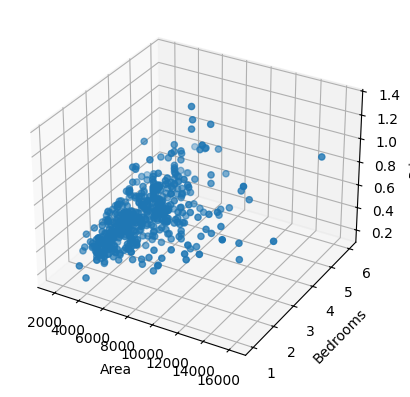

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['area'], df['bedrooms'], df['price'])

ax.set_xlabel("Area")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")

plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['furnishingstatus'])

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_furnished  furnishingstatus_semi-furnished  \
0                        True                            False   
1                        T

# Decision TREE




     Outlook Temprature humidity  windy play tennis
0      sunny        hot     high  False          no
1      sunny        hot     high   True          no
2   overcast        hot     high  False         yes
3      rainy       mild     high  False         yes
4      rainy       cold   normal  False         yes
5      rainy       cold   normal   True          no
6   overcast       cold   normal   True         yes
7      sunny       mild     high  False          no
8      sunny       cold   normal  False         yes
9      rainy       mild   normal  False         yes
10     sunny       mild   normal   True         yes
11  overcast       mild     high   True         yes
12  overcast        hot   normal  False         yes
13     rainy       mild     high   True          no
    Outlook  Temprature  humidity  windy  Play
0         2           1         0      0     0
1         2           1         0      1     0
2         0           1         0      0     1
3         1           2         

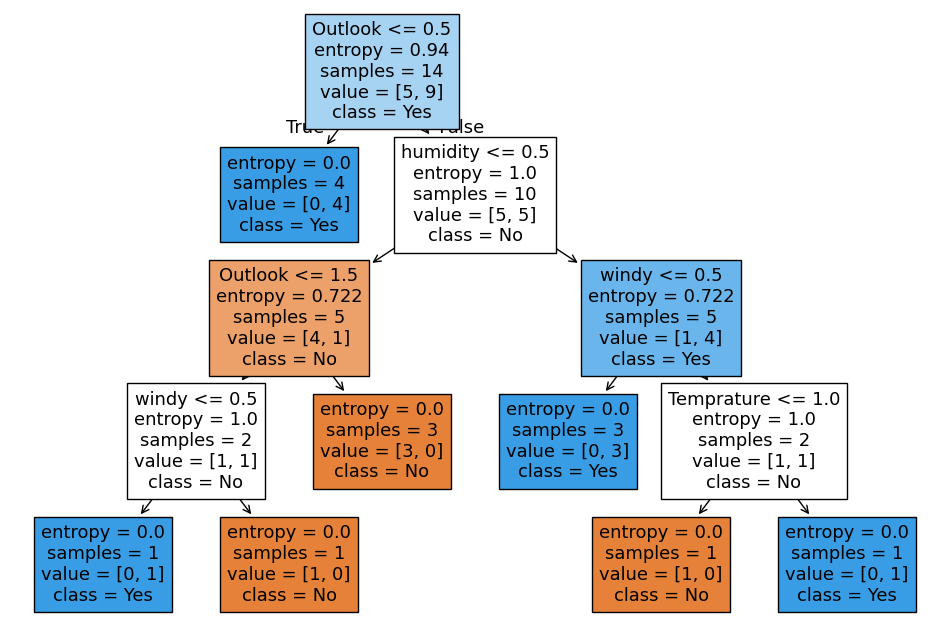

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv('Tennis.csv')

# Step 2: Clean column names (remove spaces)
df.columns = df.columns.str.strip()
print(df)
# Step 3: Rename target column (if needed)
# Change this based on your CSV
if 'play tennis' in df.columns:
    df.rename(columns={'play tennis': 'Play'}, inplace=True)
elif 'PlayTennis' in df.columns:
    df.rename(columns={'PlayTennis': 'Play'}, inplace=True)

# Step 4: Encode categorical data
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
print(df)
# Step 5: Split features and target
X = df.drop('Play', axis=1)
y = df['Play']

# Step 6: Apply Decision Tree with Entropy
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

# Step 7: Predictions
predictions = model.predict(X)
print("Predictions:", predictions)

# Step 8: Feature Importance
print("Feature Importance:", dict(zip(X.columns, model.feature_importances_)))

# Step 9: Plot Decision Tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

# Linear Regression

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
MSE: 1754318687330.6638
R2 Score: 0.6529242642153184


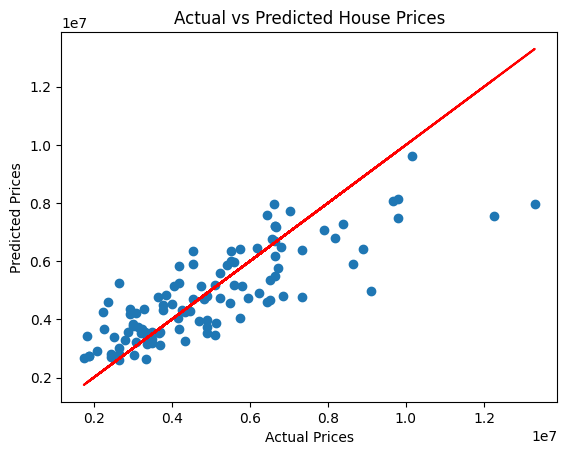

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('houseprice (1).csv')

print(df.columns)

X = df.drop('price', axis=1)
y = df['price']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

import matplotlib.pyplot as plt

# Scatter plot (Actual vs Predicted)
plt.scatter(y_test, y_pred)

# Line (perfect prediction line)
plt.plot(y_test, y_test, color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Logistic Regression

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('car_dataset (1).data')

# Clean column names
df.columns = df.columns.str.strip()

# Encode categorical data
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Split features and target
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.024390243902439025


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


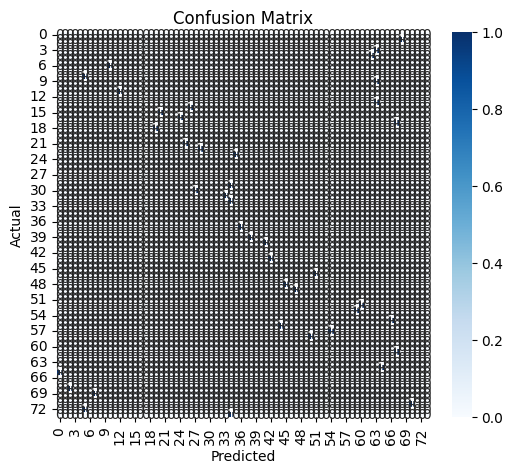

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()